Cell 1
Import Libraries

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from scipy.stats.mstats import winsorize

from scipy.stats import pearsonr
from scipy.stats import spearmanr

from sklearn.decomposition import PCA

from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib

Cell 2
Load Datasets

In [9]:
ema = pd.read_csv(
    "/kaggle/input/datasets/subigyanepal/college-experience-dataset/EMA/general_ema.csv"
)

sensing = pd.read_csv(
    "/kaggle/input/datasets/subigyanepal/college-experience-dataset/Sensing/sensing.csv"
)

In [10]:
print(ema.shape)

print(sensing.shape)

print()

print(ema.columns)

print()

print(sensing.columns)

(217155, 19)
(216065, 651)

Index(['uid', 'day', 'pam', 'phq4-1', 'phq4-2', 'phq4-3', 'phq4-4',
       'phq4_resp_mean', 'phq4_resp_median', 'phq4_score', 'social_level',
       'sse3-1', 'sse3-2', 'sse3-3', 'sse3-4', 'sse3_resp_mean',
       'sse3_resp_median', 'stress', 'avg_ema_spent_time'],
      dtype='object')

Index(['uid', 'is_ios', 'day', 'act_in_vehicle_ep_0', 'act_in_vehicle_ep_1',
       'act_in_vehicle_ep_2', 'act_in_vehicle_ep_3', 'act_in_vehicle_hr_0',
       'act_in_vehicle_hr_1', 'act_in_vehicle_hr_10',
       ...
       'unlock_num_hr_22', 'unlock_num_hr_23', 'unlock_num_hr_3',
       'unlock_num_hr_4', 'unlock_num_hr_5', 'unlock_num_hr_6',
       'unlock_num_hr_7', 'unlock_num_hr_8', 'unlock_num_hr_9',
       'sleep_heathkit_dur'],
      dtype='object', length=651)


In [ ]:
Cell 3
Stress Feature

In [11]:
stress = (

    ema

    .groupby("uid")["stress"]

    .mean()

    .reset_index()

)

stress.rename(

    columns={

        "stress":"stress"

    },

    inplace=True

)

stress.head()

,uid,stress
0,003df5deff30e1e5a07b5d063fe85c3f,1.934211
1,0107c61e54459068bb83f6be2058d65d,1.857895
2,01fb41df0f6c2f69d65db5a38c600b4c,3.769231
3,031cf9537e5da78c5a69a10cba088c94,2.072165
4,03a0ce5623bfeb8aa3113605f7682215,2.605556


In [ ]:
Cell 4
Mental Health Feature

In [12]:
mental_health = (

    ema

    .groupby("uid")["phq4_score"]

    .mean()

    .reset_index()

)

mental_health.rename(

    columns={

        "phq4_score":"mental_health"

    },

    inplace=True

)

mental_health.head()

,uid,mental_health
0,003df5deff30e1e5a07b5d063fe85c3f,0.828947
1,0107c61e54459068bb83f6be2058d65d,1.978947
2,01fb41df0f6c2f69d65db5a38c600b4c,0.923077
3,031cf9537e5da78c5a69a10cba088c94,2.804124
4,03a0ce5623bfeb8aa3113605f7682215,2.238889


Cell 5
Social Level Feature

In [13]:
social_level = (

    ema

    .groupby("uid")["social_level"]

    .mean()

    .reset_index()

)

social_level.head()

,uid,social_level
0,003df5deff30e1e5a07b5d063fe85c3f,4.164474
1,0107c61e54459068bb83f6be2058d65d,3.205263
2,01fb41df0f6c2f69d65db5a38c600b4c,1.846154
3,031cf9537e5da78c5a69a10cba088c94,2.855670
4,03a0ce5623bfeb8aa3113605f7682215,3.038889


Cell 6
Social Support Feature

In [14]:
social_support = (

    ema

    .groupby("uid")["sse3_resp_mean"]

    .mean()

    .reset_index()

)

social_support.rename(

    columns={

        "sse3_resp_mean":"social_support"

    },

    inplace=True

)

social_support.head()

,uid,social_support
0,003df5deff30e1e5a07b5d063fe85c3f,2.457498
1,0107c61e54459068bb83f6be2058d65d,6.308367
2,01fb41df0f6c2f69d65db5a38c600b4c,1.721021
3,031cf9537e5da78c5a69a10cba088c94,2.834455
4,03a0ce5623bfeb8aa3113605f7682215,2.562204


Cell 7
Sleep Feature

In [15]:
sleep = (

    sensing

    .groupby("uid")["sleep_heathkit_dur"]

    .mean()

    .reset_index()

)

sleep.rename(

    columns={

        "sleep_heathkit_dur":"sleep"

    },

    inplace=True

)

sleep.head()

,uid,sleep
0,003df5deff30e1e5a07b5d063fe85c3f,5.678334
1,0107c61e54459068bb83f6be2058d65d,2.041750
2,01fb41df0f6c2f69d65db5a38c600b4c,6.700442
3,031cf9537e5da78c5a69a10cba088c94,6.743901
4,03a0ce5623bfeb8aa3113605f7682215,6.038300


Cell 8
Merge Features

In [16]:
wellness_df = stress.merge(

    mental_health,

    on="uid",

    how="outer"

)

wellness_df = wellness_df.merge(

    social_level,

    on="uid",

    how="outer"

)

wellness_df = wellness_df.merge(

    social_support,

    on="uid",

    how="outer"

)

wellness_df = wellness_df.merge(

    sleep,

    on="uid",

    how="outer"

)

wellness_df.head()

,uid,stress,mental_health,social_level,social_support,sleep
0,003df5deff30e1e5a07b5d063fe85c3f,1.934211,0.828947,4.164474,2.457498,5.678334
1,0107c61e54459068bb83f6be2058d65d,1.857895,1.978947,3.205263,6.308367,2.041750
2,01fb41df0f6c2f69d65db5a38c600b4c,3.769231,0.923077,1.846154,1.721021,6.700442
3,031cf9537e5da78c5a69a10cba088c94,2.072165,2.804124,2.855670,2.834455,6.743901
4,03a0ce5623bfeb8aa3113605f7682215,2.605556,2.238889,3.038889,2.562204,6.038300


Cell 9
Initial Exploration

In [17]:
print("Shape:")

print(

    wellness_df.shape

)

print()

print("Unique Students:")

print(

    wellness_df["uid"].nunique()

)

print()

print("Missing Values:")

print(

    wellness_df.isnull().sum()

)

print()

print("Summary Statistics:")

print(

    wellness_df.describe()

)

print()

print("Data Types:")

print(

    wellness_df.dtypes

)

print()

print("Duplicate Rows:")

print(

    wellness_df.duplicated().sum()

)

wellness_df.head()

Shape:
(220, 6)

Unique Students:
220

Missing Values:
uid                0
stress             2
mental_health      2
social_level       2
social_support     2
sleep             39
dtype: int64

Summary Statistics:
           stress  mental_health  social_level  social_support       sleep
count  218.000000     218.000000    218.000000      218.000000  181.000000
mean     2.517821       2.463309      3.155193        8.842814    6.730458
std      0.533310       1.776603      0.456700       32.381763    2.164773
min      1.096970       0.041916      1.155844        0.702823    2.019931
25%      2.166929       1.131141      2.904428        2.150484    5.568739
50%      2.545717       2.182953      3.164945        3.029248    6.557494
75%      2.846540       3.470390      3.436921        5.208487    7.415149
max      4.493827       9.555556      4.317073      406.977596   15.990977

Data Types:
uid                object
stress            float64
mental_health     float64
social_level      f

,uid,stress,mental_health,social_level,social_support,sleep
0,003df5deff30e1e5a07b5d063fe85c3f,1.934211,0.828947,4.164474,2.457498,5.678334
1,0107c61e54459068bb83f6be2058d65d,1.857895,1.978947,3.205263,6.308367,2.041750
2,01fb41df0f6c2f69d65db5a38c600b4c,3.769231,0.923077,1.846154,1.721021,6.700442
3,031cf9537e5da78c5a69a10cba088c94,2.072165,2.804124,2.855670,2.834455,6.743901
4,03a0ce5623bfeb8aa3113605f7682215,2.605556,2.238889,3.038889,2.562204,6.038300


Cell 10 – Data Quality Assessment

In [18]:
print("=" * 60)
print("WELLNESS DATA QUALITY REPORT")
print("=" * 60)

print("\nDataset Shape")
print(wellness_df.shape)

print("\nUnique Students")
print(wellness_df["uid"].nunique())

print("\nMissing Values")
print(wellness_df.isnull().sum())

print("\nDuplicate Rows")
print(wellness_df.duplicated().sum())

print("\nData Types")
print(wellness_df.dtypes)

WELLNESS DATA QUALITY REPORT

Dataset Shape
(220, 6)

Unique Students
220

Missing Values
uid                0
stress             2
mental_health      2
social_level       2
social_support     2
sleep             39
dtype: int64

Duplicate Rows
0

Data Types
uid                object
stress            float64
mental_health     float64
social_level      float64
social_support    float64
sleep             float64
dtype: object


Cell 11
Missing Value Imputation

In [19]:
features = [
    "stress",
    "mental_health",
    "social_level",
    "social_support",
    "sleep"
]

for col in features:

    wellness_df[col] = wellness_df[col].fillna(

        wellness_df[col].median()

    )

wellness_df.isnull().sum()

uid               0
stress            0
mental_health     0
social_level      0
social_support    0
sleep             0
dtype: int64

Cell 12
Winsorization

In [21]:
clip_limits = {}

for col in features:

    lower = wellness_df[col].quantile(0.01)

    upper = wellness_df[col].quantile(0.99)

    clip_limits[col] = (

        lower,

        upper

    )

    wellness_df[col] = wellness_df[col].clip(

        lower,

        upper

    )

Cell 13
Verify Winsorization

In [22]:
wellness_df[features].describe()

,stress,mental_health,social_level,social_support,sleep
count,220.000000,220.000000,220.000000,220.000000,220.000000
mean,2.515930,2.450359,3.161210,6.933901,6.691590
std,0.515770,1.730466,0.431960,14.795995,1.903727
min,1.359192,0.067899,2.226595,0.971973,2.394366
25%,2.183848,1.140995,2.907879,2.159409,5.859519
50%,2.545717,2.182953,3.164945,3.029248,6.557494
75%,2.839619,3.450130,3.435764,5.094333,7.168632
max,3.826536,8.246161,4.228398,102.074817,13.681200


In [25]:
for col in features:

    print(col)

    print(

        wellness_df[col].min(),

        wellness_df[col].max()

    )

    print()

stress
1.359192332046332 3.8265364695065895

mental_health
0.06789892228406513 8.24616148648649

social_level
2.2265950464396287 4.228398214285715

social_support
0.9719734560812152 102.07481711426614

sleep
2.3943656995394833 13.681199962470885



Cell 14
Standardization

In [29]:
scaler = StandardScaler()

wellness_scaled = wellness_df.copy()

wellness_scaled[features] = scaler.fit_transform(

    wellness_df[features]

)

In [30]:
wellness_scaled.head()

,uid,stress,mental_health,social_level,social_support,sleep
0,003df5deff30e1e5a07b5d063fe85c3f,-1.130438,-0.939117,2.327878,-0.303231,-0.533462
1,0107c61e54459068bb83f6be2058d65d,-1.278740,-0.273040,0.102217,-0.042374,-2.262417
2,01fb41df0f6c2f69d65db5a38c600b4c,2.435502,-0.884597,-2.168593,-0.353120,0.004660
3,031cf9537e5da78c5a69a10cba088c94,-0.862355,0.204899,-0.708946,-0.277696,0.027541
4,03a0ce5623bfeb8aa3113605f7682215,0.174167,-0.122483,-0.283823,-0.296139,-0.343946


Cell 15
Distribution Check

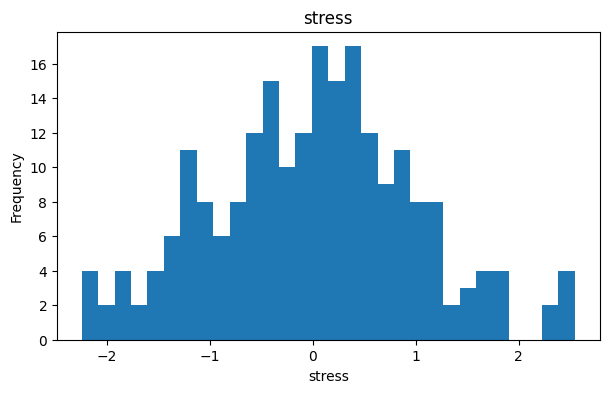

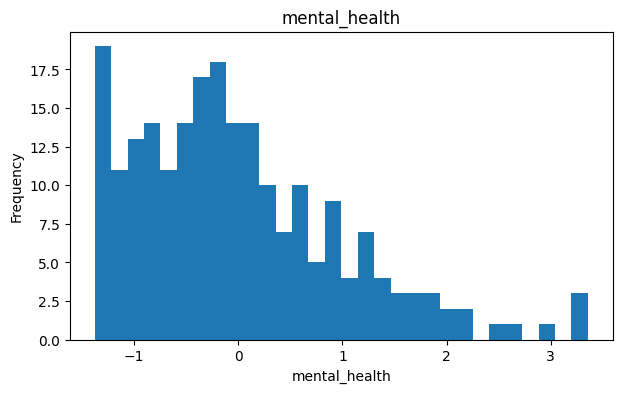

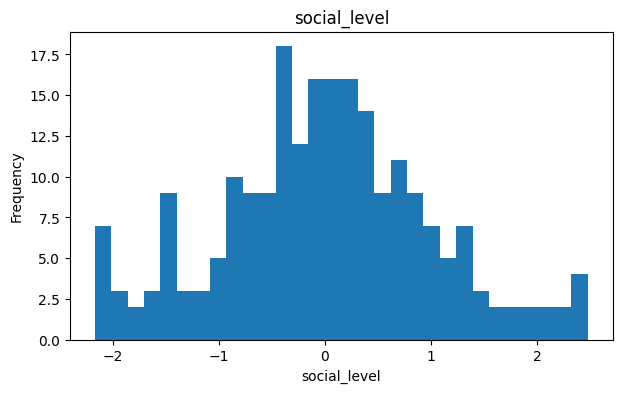

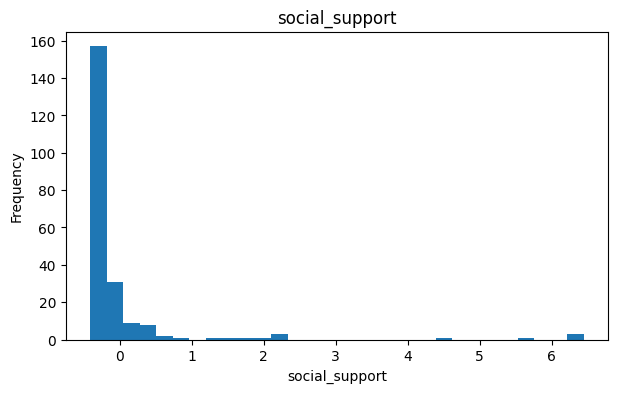

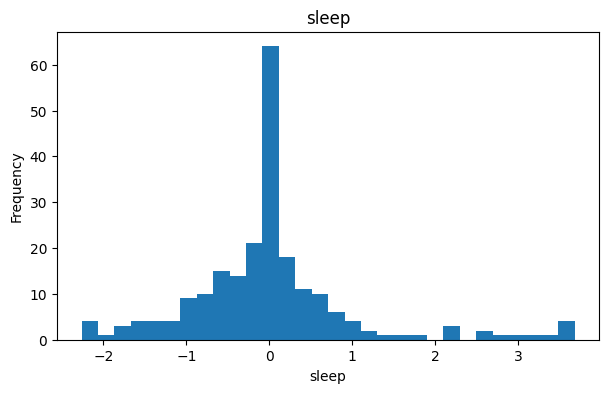

In [31]:
for col in features:

    plt.figure(figsize=(7,4))

    plt.hist(

        wellness_scaled[col],

        bins=30

    )

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

Cell 16 – Pearson Correlation Analysis

In [32]:
pearson_corr = wellness_scaled[
    features
].corr(method="pearson")

print("Pearson Correlation Matrix")
print()

print(pearson_corr)

Pearson Correlation Matrix

                  stress  mental_health  social_level  social_support  \
stress          1.000000       0.644975     -0.083799        0.023226   
mental_health   0.644975       1.000000     -0.054860        0.124156   
social_level   -0.083799      -0.054860      1.000000       -0.081847   
social_support  0.023226       0.124156     -0.081847        1.000000   
sleep          -0.051835      -0.063975      0.005183       -0.064471   

                   sleep  
stress         -0.051835  
mental_health  -0.063975  
social_level    0.005183  
social_support -0.064471  
sleep           1.000000  


Cell 17 – Spearman Correlation Analysis

In [33]:
spearman_corr = wellness_scaled[
    features
].corr(method="spearman")

print("Spearman Correlation Matrix")
print()

print(spearman_corr)

Spearman Correlation Matrix

                  stress  mental_health  social_level  social_support  \
stress          1.000000       0.633622     -0.101848       -0.119247   
mental_health   0.633622       1.000000     -0.114051        0.070080   
social_level   -0.101848      -0.114051      1.000000        0.205649   
social_support -0.119247       0.070080      0.205649        1.000000   
sleep          -0.056457      -0.095970      0.035300        0.023431   

                   sleep  
stress         -0.056457  
mental_health  -0.095970  
social_level    0.035300  
social_support  0.023431  
sleep           1.000000  


Cell 18 – Correlation Heatmap

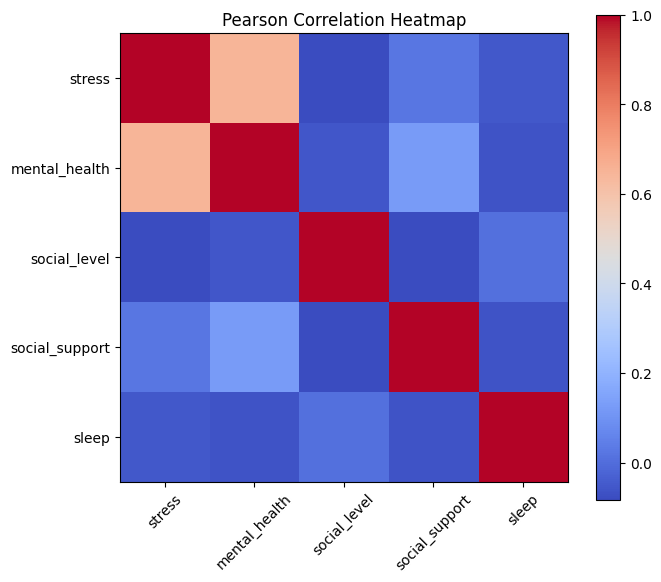

In [34]:
plt.figure(figsize=(7,6))

plt.imshow(
    pearson_corr,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(features)),
    features,
    rotation=45
)

plt.yticks(
    range(len(features)),
    features
)

plt.title("Pearson Correlation Heatmap")

plt.tight_layout()

plt.show()

Cell 19 – Multicollinearity Analysis (VIF)

In [35]:
vif_df = pd.DataFrame()

vif_df["Feature"] = features

vif_df["VIF"] = [

    variance_inflation_factor(

        wellness_scaled[features].values,

        i

    )

    for i in range(len(features))

]

print(vif_df)

          Feature       VIF
0          stress  1.730941
1   mental_health  1.749913
2    social_level  1.013720
3  social_support  1.031644
4           sleep  1.007743


Cell 20 – Principal Component Analysis

In [37]:
pca = PCA()

wellness_pca = pca.fit_transform(

    wellness_scaled[
        features
    ]

)

In [38]:
explained_variance = pd.DataFrame({

    "Principal Component":[

        f"PC{i+1}"

        for i in range(

            len(pca.explained_variance_ratio_)

        )

    ],

    "Explained Variance":

        pca.explained_variance_ratio_

})

print(explained_variance)

  Principal Component  Explained Variance
0                 PC1            0.338290
1                 PC2            0.212658
2                 PC3            0.199103
3                 PC4            0.180779
4                 PC5            0.069169


In [39]:
loadings = pd.DataFrame(

    pca.components_.T,

    columns=[

        f"PC{i+1}"

        for i in range(

            len(features)

        )

    ],

    index=features

)

print(loadings)

                     PC1       PC2       PC3       PC4       PC5
stress          0.674978 -0.234133  0.021840 -0.051208 -0.697487
mental_health   0.686108 -0.147458 -0.020548  0.093159  0.705982
social_level   -0.158163 -0.505478 -0.633605  0.562175 -0.044493
social_support  0.176876  0.703032  0.005655  0.679202 -0.114515
sleep          -0.131758 -0.416744  0.773054  0.459720  0.002842


Cell 21 – Wellness Representation

In [41]:
wellness_representation = pd.DataFrame({

    "uid":

        wellness_df["uid"],

    "Wellness_PC1":

        wellness_pca[:,0],

    "Wellness_PC2":

        wellness_pca[:,1]

})

Cell 22 – Representation Statistics

In [42]:
print()

print("Representation Shape")

print(

    wellness_representation.shape

)

print()

print(

    wellness_representation.describe()

)


Representation Shape
(220, 3)

       Wellness_PC1  Wellness_PC2
count  2.200000e+02  2.200000e+02
mean   1.614870e-17  1.110223e-17
std    1.303524e+00  1.033510e+00
min   -2.627778e+00 -2.700449e+00
25%   -8.952791e-01 -4.828014e-01
50%   -1.745748e-01 -8.303774e-02
75%    8.853821e-01  3.498599e-01
max    4.058504e+00  6.223434e+00


Cell 23 – Wellness Representation Visualization

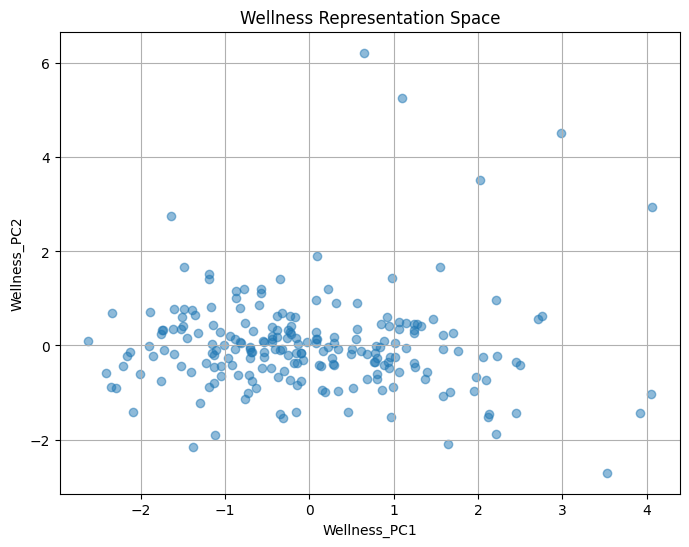

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    wellness_representation["Wellness_PC1"],
    wellness_representation["Wellness_PC2"],
    alpha=0.5
)

plt.title("Wellness Representation Space")

plt.xlabel("Wellness_PC1")

plt.ylabel("Wellness_PC2")

plt.grid(True)

plt.show()

Cell 24 – Explained Variance

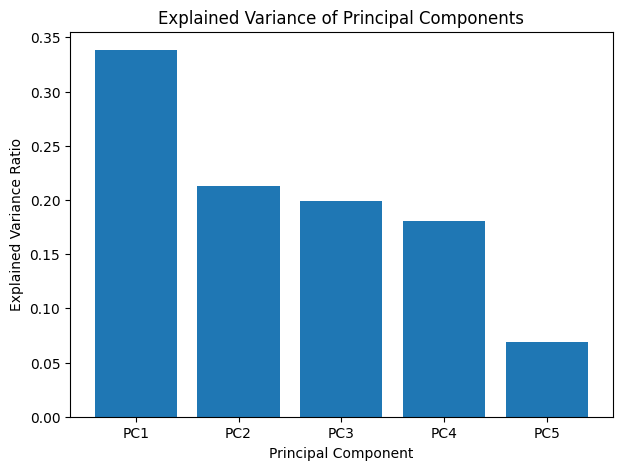

In [44]:
plt.figure(figsize=(7,5))

plt.bar(
    explained_variance["Principal Component"],
    explained_variance["Explained Variance"]
)

plt.title("Explained Variance of Principal Components")

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance Ratio")

plt.show()

Cell 25 – Cumulative Explained Variance

In [45]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

variance_df = pd.DataFrame({

    "Principal Component":[
        "PC1",
        "PC2",
        "PC3",
        "PC4",
        "PC5"
    ],

    "Explained Variance":
        pca.explained_variance_ratio_,

    "Cumulative Variance":
        cumulative_variance
})

print(variance_df)

  Principal Component  Explained Variance  Cumulative Variance
0                 PC1            0.338290             0.338290
1                 PC2            0.212658             0.550948
2                 PC3            0.199103             0.750051
3                 PC4            0.180779             0.930831
4                 PC5            0.069169             1.000000


Cell 26 – Representation Correlation

In [46]:
representation_corr = (
    wellness_representation[
        [
            "Wellness_PC1",
            "Wellness_PC2"
        ]
    ]
    .corr()
)

print(representation_corr)

              Wellness_PC1  Wellness_PC2
Wellness_PC1  1.000000e+00  1.063513e-16
Wellness_PC2  1.063513e-16  1.000000e+00


Cell 27 – Validation Report

In [47]:
print("="*60)
print("WELLNESS REPRESENTATION VALIDATION REPORT")
print("="*60)

print("\nNumber of Students:")
print(len(wellness_representation))

print("\nRepresentation Shape:")
print(wellness_representation.shape)

print("\nMissing Values:")
print(wellness_representation.isnull().sum())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nCumulative Explained Variance:")
print(np.cumsum(
    pca.explained_variance_ratio_
))

print("\nCorrelation Between Components:")
print(
    wellness_representation[
        [
            "Wellness_PC1",
            "Wellness_PC2"
        ]
    ].corr()
)

WELLNESS REPRESENTATION VALIDATION REPORT

Number of Students:
220

Representation Shape:
(220, 3)

Missing Values:
uid             0
Wellness_PC1    0
Wellness_PC2    0
dtype: int64

Explained Variance Ratio:
[0.33829029 0.2126577  0.19910335 0.18077919 0.06916948]

Cumulative Explained Variance:
[0.33829029 0.55094799 0.75005133 0.93083052 1.        ]

Correlation Between Components:
              Wellness_PC1  Wellness_PC2
Wellness_PC1  1.000000e+00  1.063513e-16
Wellness_PC2  1.063513e-16  1.000000e+00


Cell 28 – Save Wellness Representation

In [49]:
wellness_representation.to_csv(

    "wellness_representation.csv",

    index=False

)

Cell 29 – Save Models

In [50]:
joblib.dump(

    scaler,

    "wellness_scaler.pkl"

)

joblib.dump(

    clip_limits,

    "wellness_clip_limits.pkl"

)

joblib.dump(

    pca,

    "wellness_pca.pkl"

)

['wellness_pca.pkl']

Cell 30 – Verify Saved Files

In [52]:
import os

files = [

    "wellness_representation.csv",

    "wellness_scaler.pkl",

    "wellness_clip_limits.pkl",

    "wellness_pca.pkl"

]

print("="*60)
print("FILES SAVED")
print("="*60)

for file in files:

    print(

        file,

        "✓"

        if os.path.exists(file)

        else "✗"

    )

FILES SAVED
wellness_representation.csv ✓
wellness_scaler.pkl ✓
wellness_clip_limits.pkl ✓
wellness_pca.pkl ✓
